# **LangChain Agents**

### **Objective:**  
To understand how to create, configure, and use **LangChain Agents**. This demo demonstrates initializing an agent, loading tools, and using the agent to perform actions such as mathematical calculations, web searches, and retrieving information from Wikipedia.

---

### **Note:**  
- Before running any demo, ensure that the **requirements.txt** file is installed. This file contains all the required dependencies for **all demos and guided practices under Building LLM Applications**.
- If the dependencies were already installed earlier (after creating the virtual environment), there is no need to install them again. You can directly proceed with running the demo.
- Refer to Lesson_01 **Demo_01_Zero_Shot_Prompting.ipynb** Step 1 for creating a virtual environment and installing the requirements.txt 
- Ensure you select the right kernel **Python (myenv)** while running the demos.
- You will need a valid **SerpAPI key** for live Google search queries.  
---

### **Steps to perform:**
1. Import the necessary modules  
2. Initialize the chat model  
3. Load the tools  
4. Initialize the agent  
5. Use the agent to ask questions  
6. Use the agent to ask another question  

---


### **Step 1: Import the necessary modules**
- Import essential LangChain modules for tools, agents, and chat models

In [1]:
from langchain_openai import ChatOpenAI
from langchain_community.utilities import WikipediaAPIWrapper, SerpAPIWrapper
from langchain_community.tools import WikipediaQueryRun
from langchain_experimental.tools.python.tool import PythonREPLTool
#from langchain_experimental.utilities import PythonREPL
from langchain_core.tools import tool
from langchain.agents import create_agent
from typing import List


# **Step 2: Initialize the chat model**

- Initialize the ChatOpenAI model, which serves as the reasoning engine behind the agent



In [3]:

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.0)  


In [4]:
serpapi_key = ""  # ADD YOUR SERPAPI KEY HERE

# **Step 3: Load the tools**


- Define tools that the agent can use for external data access or computations.

- The tools include:
  - SerpAPI Search Tool for live Google searches
  - Wikipedia Tool for encyclopedia lookups
  - Math REPL Tool for executing Python expressions and math operations





In [5]:
@tool
def search_tool(query: str) -> str:
    """Search Google for current information using SerpAPI."""
    return SerpAPIWrapper(serpapi_api_key=serpapi_key).run(query)

@tool
def wikipedia_tool(query: str) -> str:
    """Search Wikipedia for detailed information."""
    wiki_api = WikipediaAPIWrapper()
    return WikipediaQueryRun(api_wrapper=wiki_api).run(query)

@tool
def math_tool(expression: str) -> str:
    """Execute math operations and Python expressions (replaces llm-math)."""
    return PythonREPLTool().run(expression)


In [6]:
tools = [search_tool,wikipedia_tool, math_tool]
print("✅ Tools loaded: SerpAPI Search, Math REPL")


✅ Tools loaded: SerpAPI Search, Math REPL


- These tools enable the agent to extend beyond language reasoning and access real-time data or perform computations.

### **Step 4: Initialize the agent**
- Combine the loaded tools and chat model into a unified LangChain agent


In [7]:


agent_executor = create_agent(llm,tools)

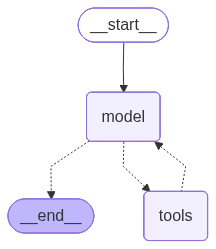

In [8]:
agent_executor

In [9]:
# agent_executorf ask_agent(question: str) -> str:
# #     """Ask the agent a question and return the final answer."""
# #     result = agent_executor.invoke({"messages": [("human", question)]})
# #     #print(result)
# #     return result["messages"][-1].content


In [ ]:
def ask_agent(question: str):

    result = agent_executor.invoke({
        "messages": [("human", question)]
    })

    final_answer = ""
    tool_used = ""

    for msg in result["messages"]:

        # Get tool name
        if msg.__class__.__name__ == "ToolMessage":
            tool_used = msg.name

        # Get final AI response
        if msg.__class__.__name__ == "AIMessage" and msg.content:
            final_answer = msg.content

    # print("Tool Used :", tool_used)
    # print("Final Answer :", final_answer)

    return {
        "tool": tool_used,
        "answer": final_answer
    }

In [ ]:
agent_executor.invoke({
        "messages": "What is the square of 5?"
    })

- The create_agent() function wraps tools and the model together, enabling autonomous reasoning and execution.

### **Step 5: Use tge agent to ask questions**
- Use the agent to solve problems or answer factual queries




In [ ]:
ask_agent("What is the square of 5?")


### **Step 6: Use agent to ask another question**
- Ask an open-ended question that requires retrieving information from Wikipedia



- Additional Example Questions


In [ ]:
ask_agent("Who is the current president of USA")


In [ ]:
ask_agent("What was the price of bitcoin on 31st may 2026?")


In [ ]:
ask_agent("What was the price of bitcoin yesterday")


In [ ]:
ask_agent("Can you justify the fluctuation in price of bitcoin")

In [ ]:
ask_agent("what is use of wikipedia")

In [ ]:
ask_agent("what is top products sold in amazon india on june1st")

- These queries combine Wikipedia and SerpAPI tools, demonstrating the agent’s capability to fetch and reason over both static and real-time data sources.

### __Conclusion__

By following these steps, you learned how to create and utilize a LangChain Agent capable of reasoning, searching, and performing calculations. You integrated tools like SerpAPI, Wikipedia, and Math REPL into the agent, allowing it to handle both factual and computational queries.

LangChain Agents are powerful for building autonomous, multi-tool AI systems that can interpret, search, calculate, and provide comprehensive, context-aware answers.

---